# **实验5: 聚类实验**

姓名：李昌峻

学号：2023213851

提交要求：每周三20:00前提交，用pdf导出，在学习通上提交pdf文件和ipynb文件，命名方式：学号_实验X。

## 一、实验目标实验目的
* 掌握聚类算法的基本原理：深入理解K-means、层次聚类、DBSCAN等常用聚类算法的工作原理和适用场景。

* 比较不同聚类算法的性能：使用相同的数据集，对比不同聚类算法在聚类质量（如轮廓系数Silhouette Score、
Calinski-Harabasz Index等指标）、计算效率、对噪声数据的敏感度等方面的表现，分析各算法的优缺点。

* 数据预处理的重要性：通过数据标准化、降维（如PCA）等预处理步骤，观察这些处理对聚类结果的影响，
    理解数据预处理在提升聚类效果中的作用。
  
* 参数调优：针对特定聚类算法（如K-means中的K值选择），探索参数调整对聚类结果的影响，学习如何根据
    实际情况选择合适的参数值。


## 二、 实验步骤

### 1. 数据准备与预处理
  
* 选择或收集一个适合聚类分析的数据集（其中一个为月牙形数据）。

* * 实施数据标准化或归一化，确保各特征在聚类过程中的贡献度相等。

### 2. 算法选择与实现
  
* 选择K-means、层次聚类、DBSCAN等至少两种聚类算法进行实现。

* 对于每种算法，根据数据特性和实验目的，合理设置算法参数（如K-means的K值、DBSCAN的ε和MinPts等）。

### 3. 聚类执行与结果评估
  
* 使用选定的算法对数据集进行聚类。

* 评估聚类结果，计算并比较不同算法的聚类质量指标。

* 可视化聚类结果，使用散点图、树状图等图形展示聚类效果，便于直观理解。
理解。）。

D:\Software\Anaconda\envs\pytorchlearning\lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
D:\Software\Anaconda\envs\pytorchlearning\lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
D:\Software\Anaconda\envs\pytorchlearning\lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


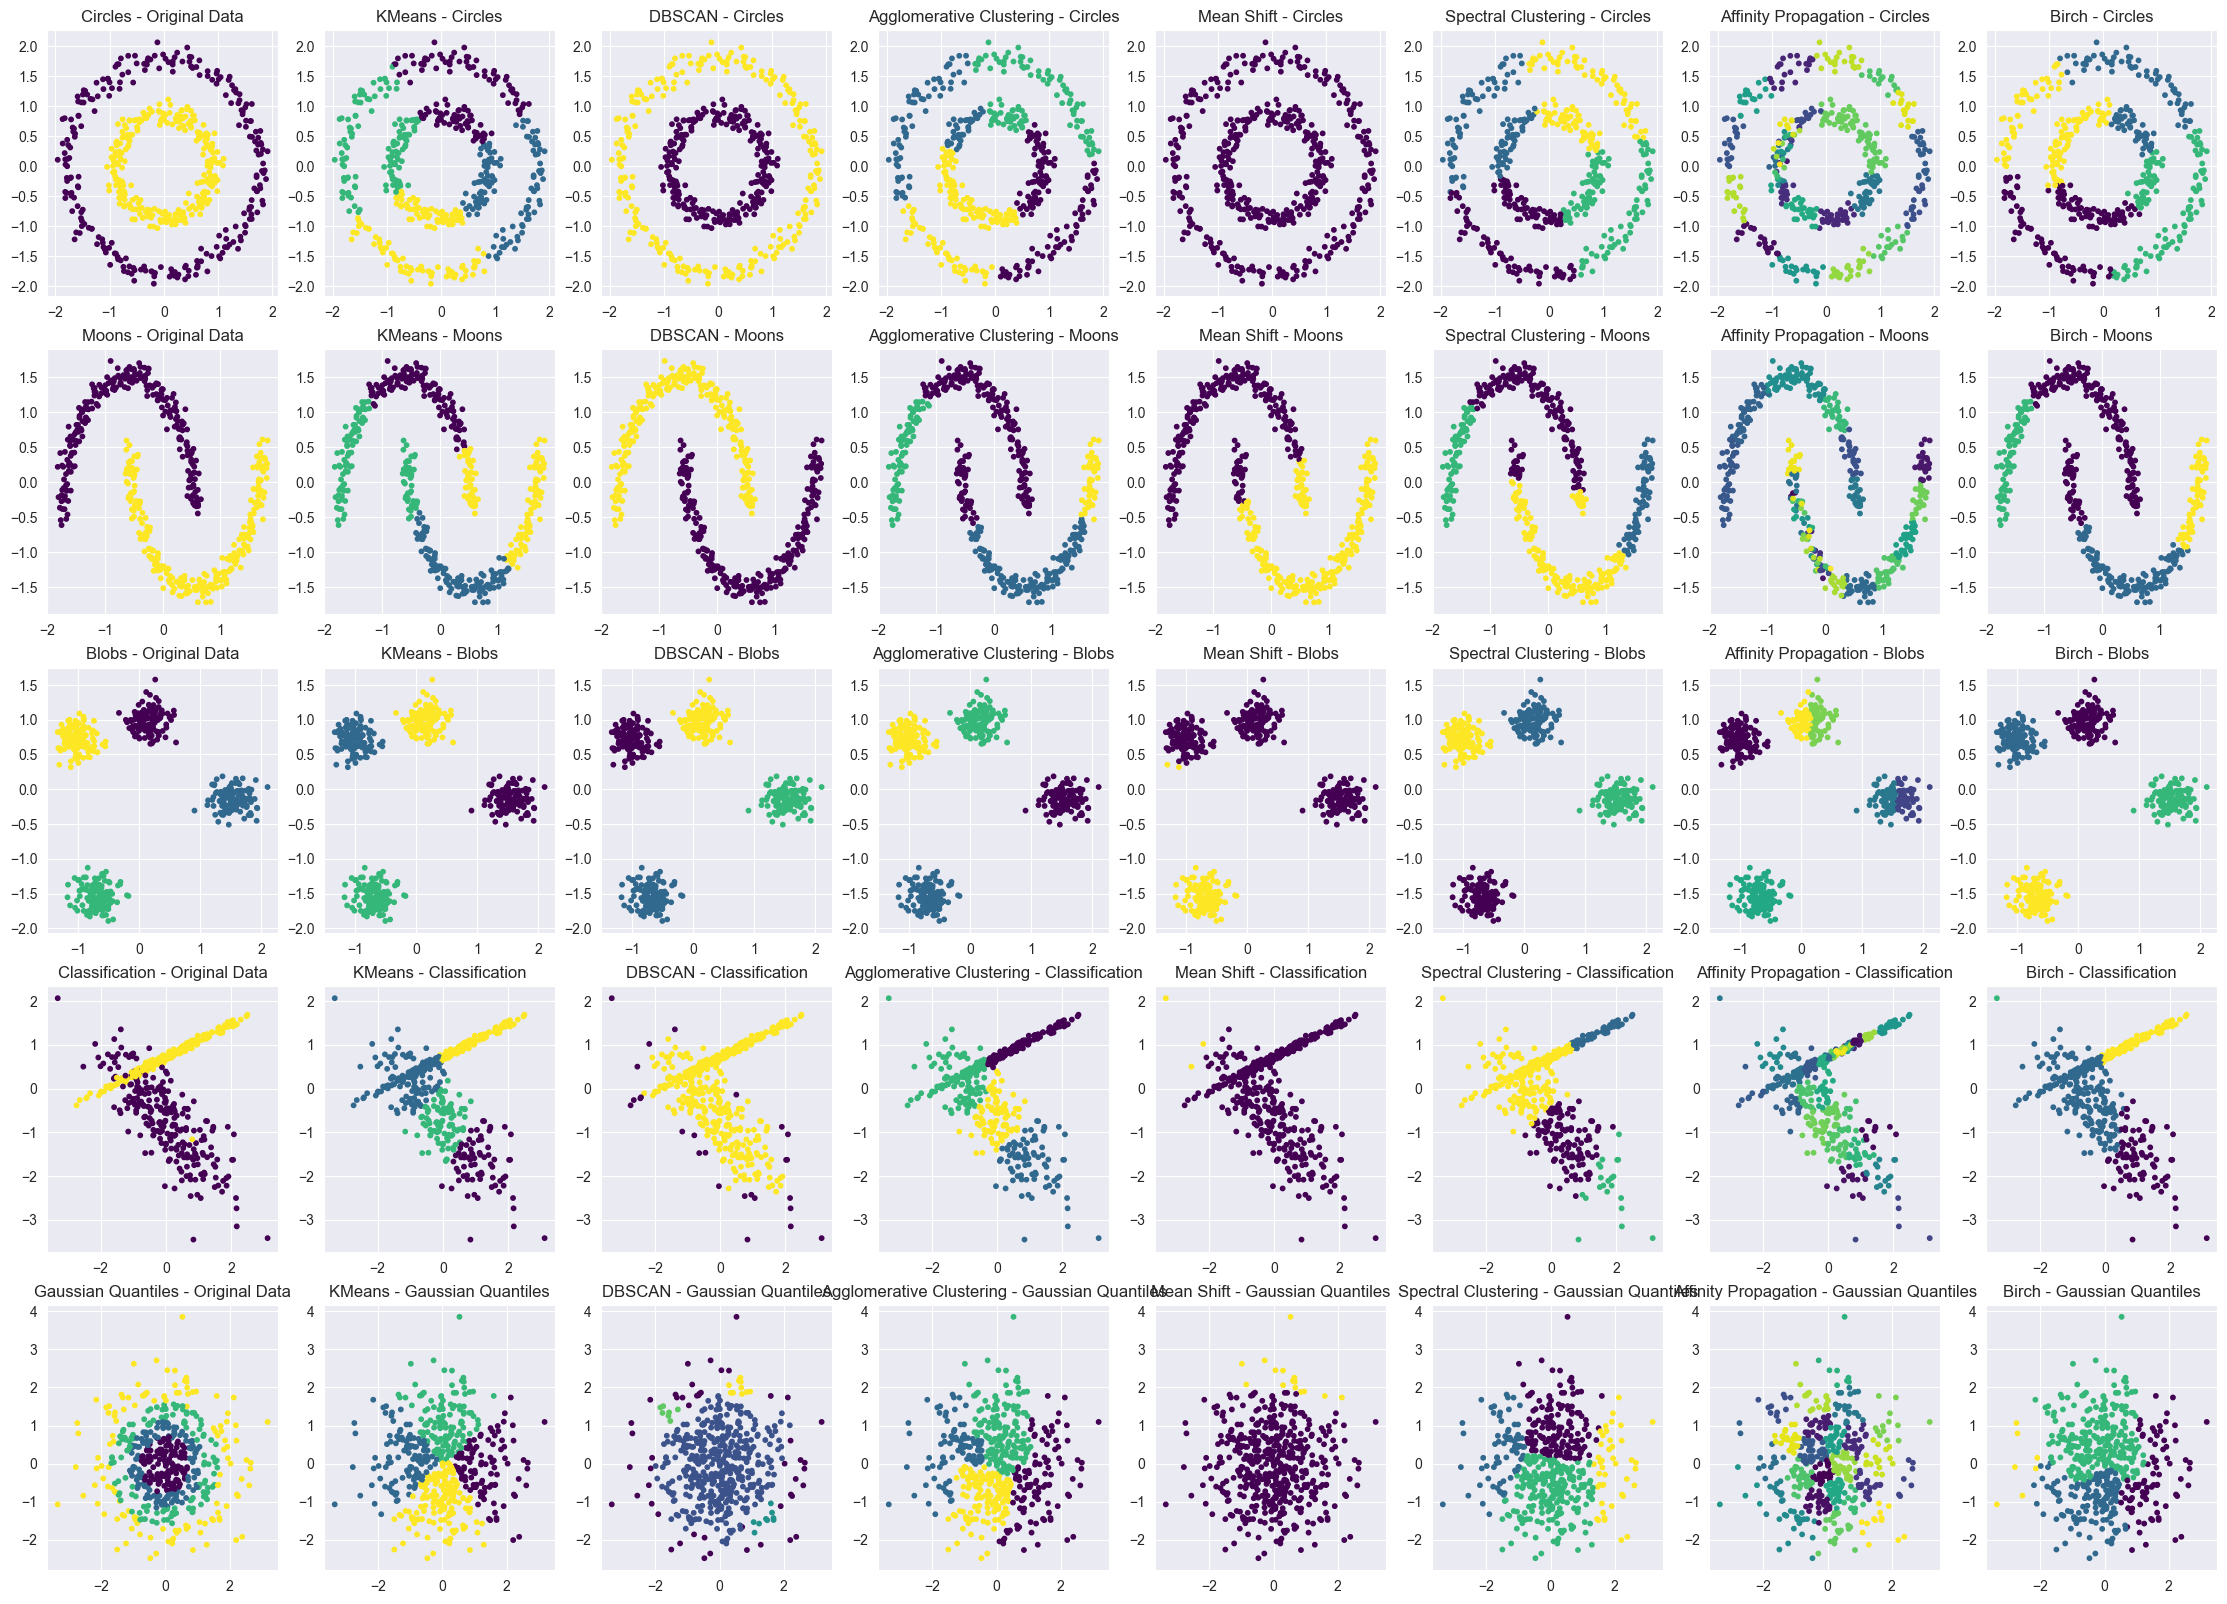

D:\Software\Anaconda\envs\pytorchlearning\lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(
D:\Software\Anaconda\envs\pytorchlearning\lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


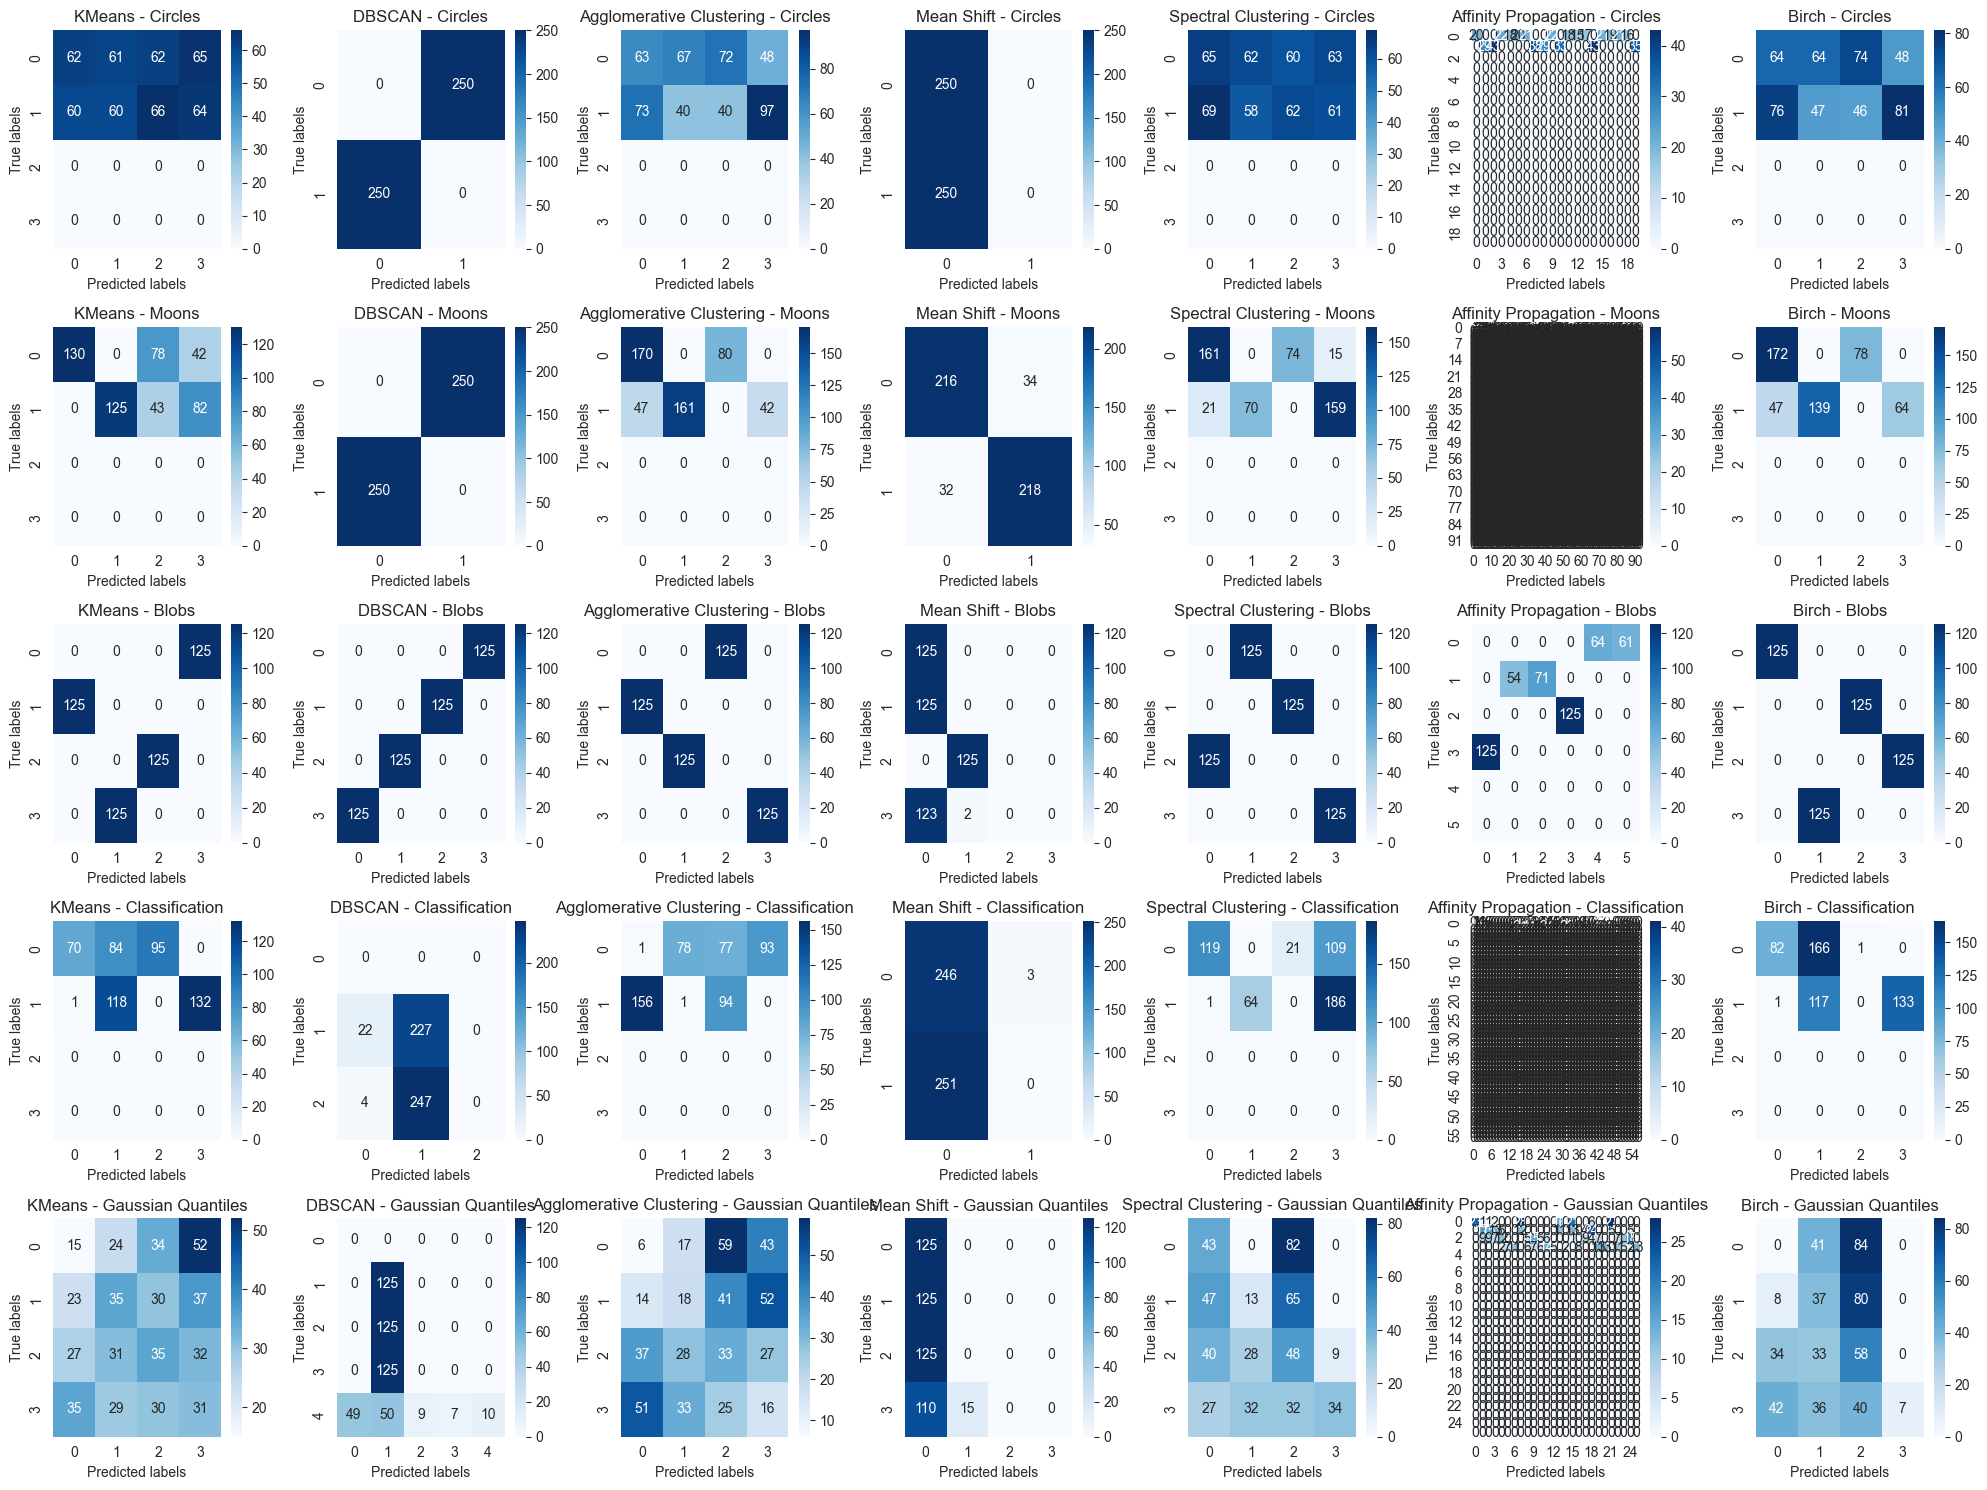

In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons, make_blobs, make_classification, make_gaussian_quantiles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, SpectralClustering, AffinityPropagation, Birch
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
import seaborn as sns

# Prepare datasets
X_circle, y_circle = make_circles(n_samples=500, factor=.5, noise=.05, random_state=42)
X_moon, y_moon = make_moons(n_samples=500, noise=.05, random_state=42)
X_cluster, y_cluster = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
X_classification, y_classification = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_gaussian, y_gaussian = make_gaussian_quantiles(n_samples=500, n_features=2, n_classes=4, random_state=42)

datasets = {
    "Circles": (X_circle, y_circle),
    "Moons": (X_moon, y_moon),
    "Blobs": (X_cluster, y_cluster),
    "Classification": (X_classification, y_classification),
    "Gaussian Quantiles": (X_gaussian, y_gaussian)
}

algorithms = {
    "KMeans": lambda X: KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X),
    "DBSCAN": lambda X: DBSCAN(eps=0.3, min_samples=5).fit_predict(X),
    "Agglomerative Clustering": lambda X: AgglomerativeClustering(n_clusters=4).fit_predict(X),
    "Mean Shift": lambda X: MeanShift().fit_predict(X),
    "Spectral Clustering": lambda X: SpectralClustering(n_clusters=4, random_state=42).fit_predict(X),
    "Affinity Propagation": lambda X: AffinityPropagation().fit_predict(X),
    "Birch": lambda X: Birch(n_clusters=4).fit_predict(X)
}

fig, axes = plt.subplots(len(datasets), len(algorithms) + 1 ,figsize=(28,20))

for row_idx, (name, (X, y)) in enumerate(datasets.items()):
    X_scaled = StandardScaler().fit_transform(X)

    axes[row_idx, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', s=10)
    axes[row_idx, 0].set_title(f"{name} - Original Data")

    for col_idx, (algo_name, algo_func) in enumerate(algorithms.items(), start=1):
        y_pred = algo_func(X_scaled)
        axes[row_idx, col_idx].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis', s=10)
        axes[row_idx, col_idx].set_title(f"{algo_name} - {name}")
plt.show()

fig_confusion_matrix, axes_confusion_matrix = plt.subplots(len(datasets), len(algorithms), figsize=(20, 15))
# 计算并绘制混淆矩阵
for row_idx, (name, (X, y)) in enumerate(datasets.items()):
    X_scaled = StandardScaler().fit_transform(X)

    for col_idx, (algo_name, algo_func) in enumerate(algorithms.items()):
        y_pred = algo_func(X_scaled)

        cm = confusion_matrix(y, y_pred)
        blue_palette = sns.color_palette("Blues", as_cmap=True)

        sns.heatmap(cm, annot=True, fmt='d', ax=axes_confusion_matrix[row_idx, col_idx], cmap=blue_palette, edgecolor='b')
        axes_confusion_matrix[row_idx, col_idx].set_title(f"{algo_name} - {name}")
        axes_confusion_matrix[row_idx, col_idx].set_xlabel('Predicted labels')
        axes_confusion_matrix[row_idx, col_idx].set_ylabel('True labels')

plt.tight_layout()
plt.show()
